Variables after cleaning:    38
Observations after cleaning: 253


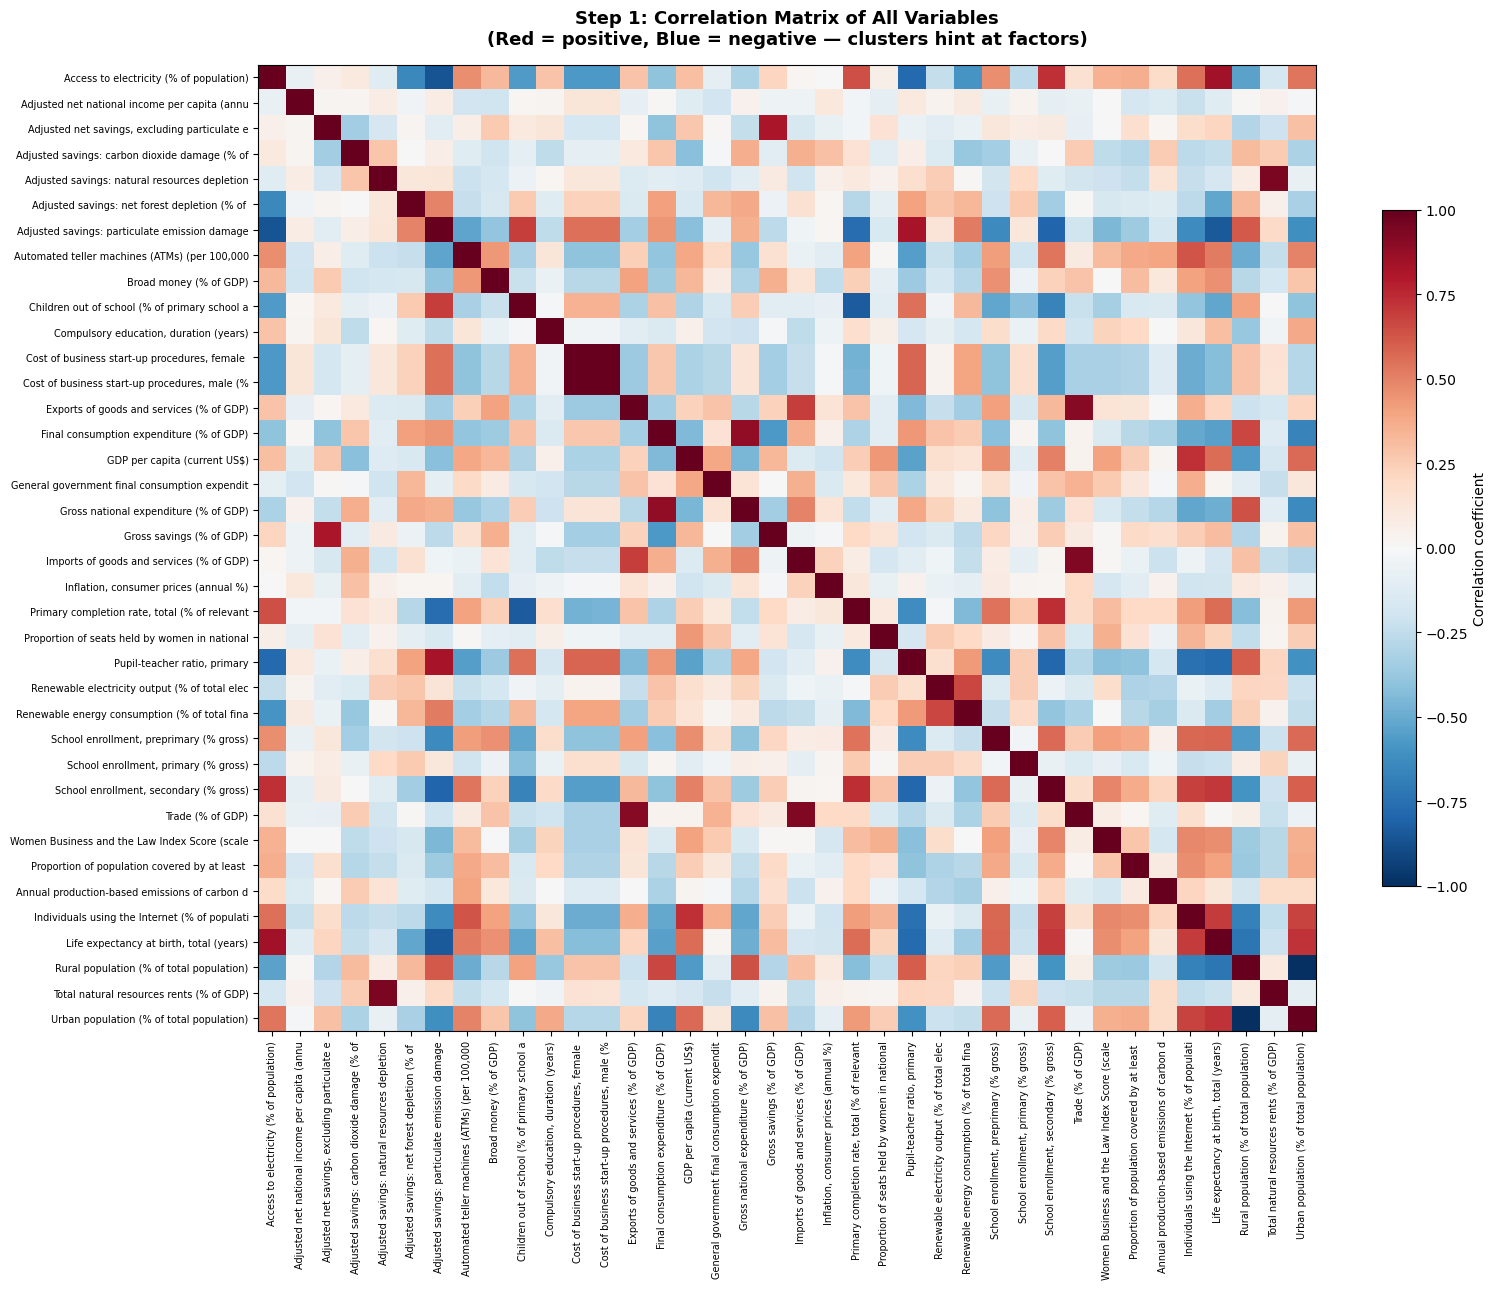

Saved: step1_correlation_matrix.png

Kaiser criterion: 10 factors have eigenvalue > 1

Eigenvalues for first 12 factors:
  Factor  1: eigenvalue = 11.525  | cumulative variance = 30.2% <- keep
  Factor  2: eigenvalue = 4.206  | cumulative variance = 41.2% <- keep
  Factor  3: eigenvalue = 3.117  | cumulative variance = 49.4% <- keep
  Factor  4: eigenvalue = 2.638  | cumulative variance = 56.3% <- keep
  Factor  5: eigenvalue = 2.266  | cumulative variance = 62.3% <- keep
  Factor  6: eigenvalue = 1.662  | cumulative variance = 66.6% <- keep
  Factor  7: eigenvalue = 1.553  | cumulative variance = 70.7% <- keep
  Factor  8: eigenvalue = 1.403  | cumulative variance = 74.4% <- keep
  Factor  9: eigenvalue = 1.225  | cumulative variance = 77.6% <- keep
  Factor 10: eigenvalue = 1.066  | cumulative variance = 80.4% <- keep
  Factor 11: eigenvalue = 0.969  | cumulative variance = 82.9%
  Factor 12: eigenvalue = 0.882  | cumulative variance = 85.2%


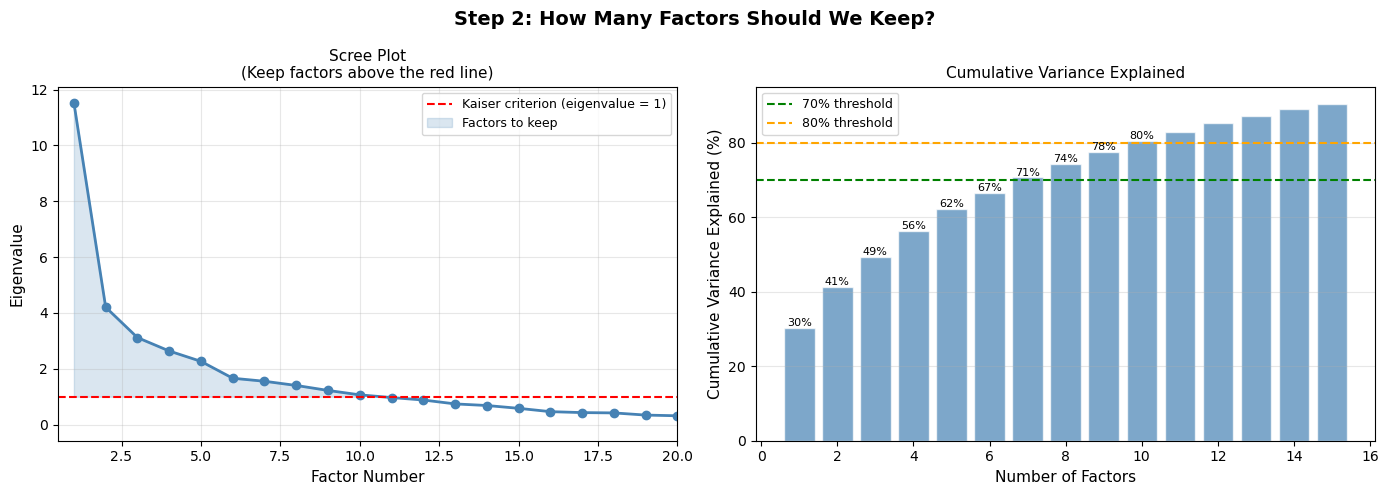

Saved: step2_scree_plot.png

TOP VARIABLES PER FACTOR  (|loading| > 0.45)

Factor 1  (30.2% variance explained)
--------------------------------------------------
  HIGH (+0.91)  Adjusted savings: particulate emission damage
  LOW  (-0.87)  School enrollment, secondary (% gross)
  LOW  (-0.86)  Access to electricity (% of population)
  HIGH (+0.84)  Pupil-teacher ratio, primary
  LOW  (-0.83)  Life expectancy at birth, total (years)
  LOW  (-0.82)  Primary completion rate, total (% of relevant
  HIGH (+0.77)  Children out of school (% of primary school a
  HIGH (+0.68)  Rural population (% of total population)
  LOW  (-0.68)  Urban population (% of total population)
  LOW  (-0.68)  Individuals using the Internet (% of populati
  LOW  (-0.66)  School enrollment, preprimary (% gross)
  LOW  (-0.57)  Women Business and the Law Index Score (scale
  HIGH (+0.56)  Cost of business start-up procedures, female 
  HIGH (+0.56)  Cost of business start-up procedures, male (%
  LOW  (-0.54)  Autom

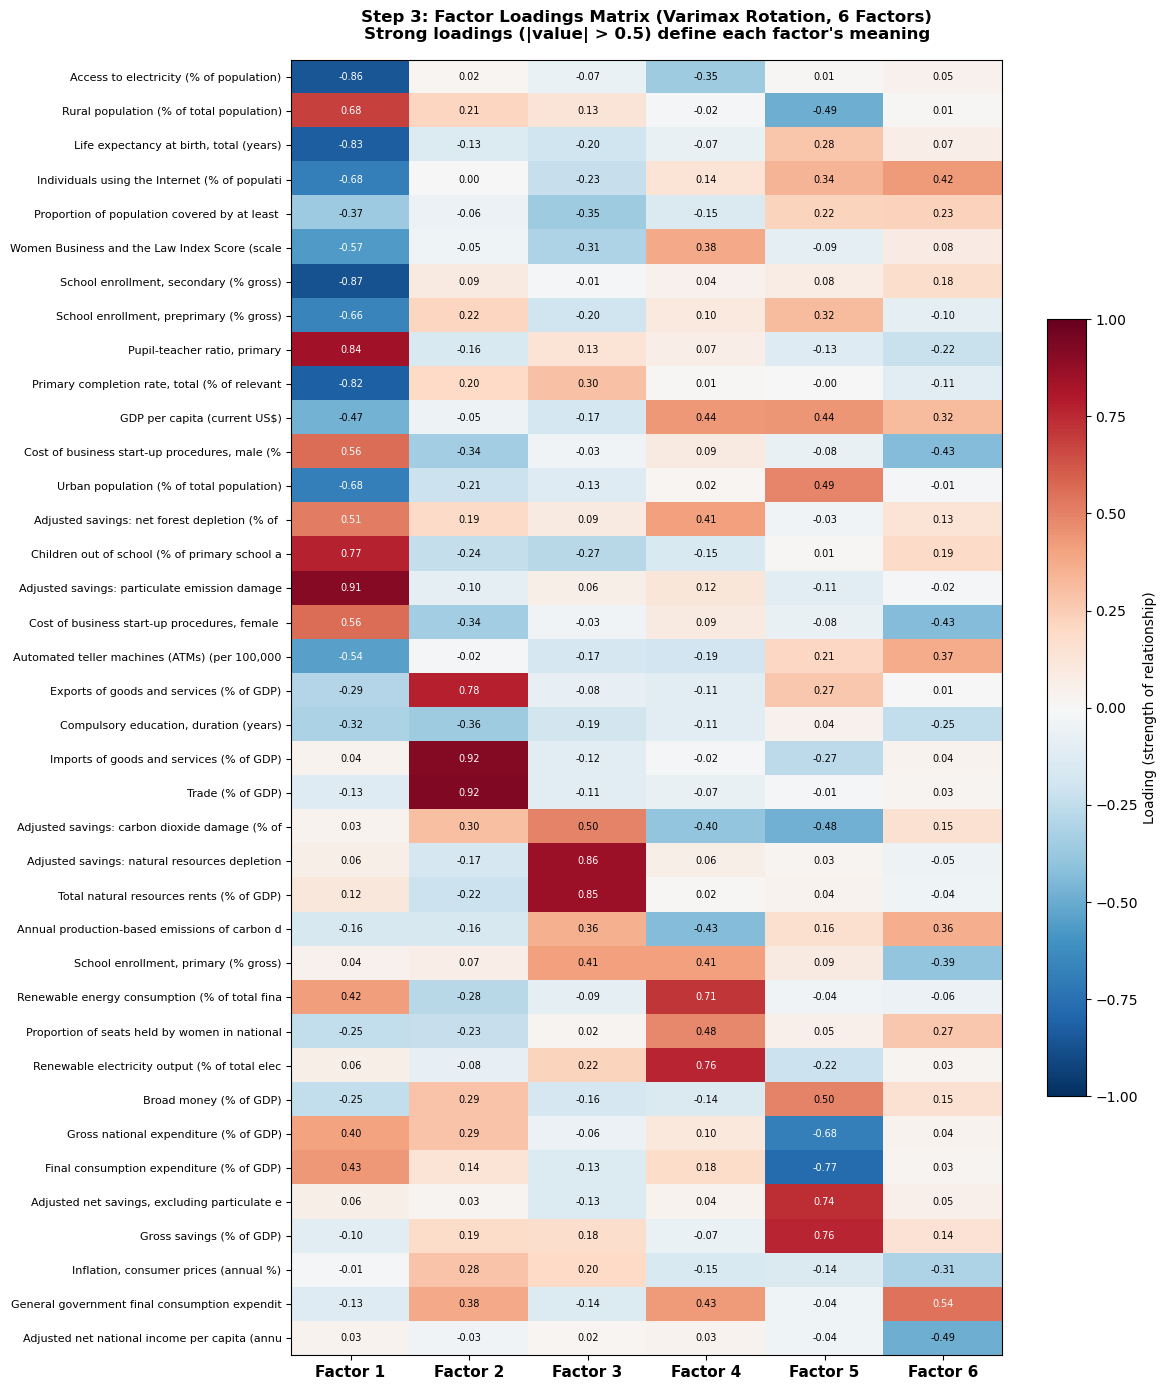

Saved: step3_factor_loadings.png


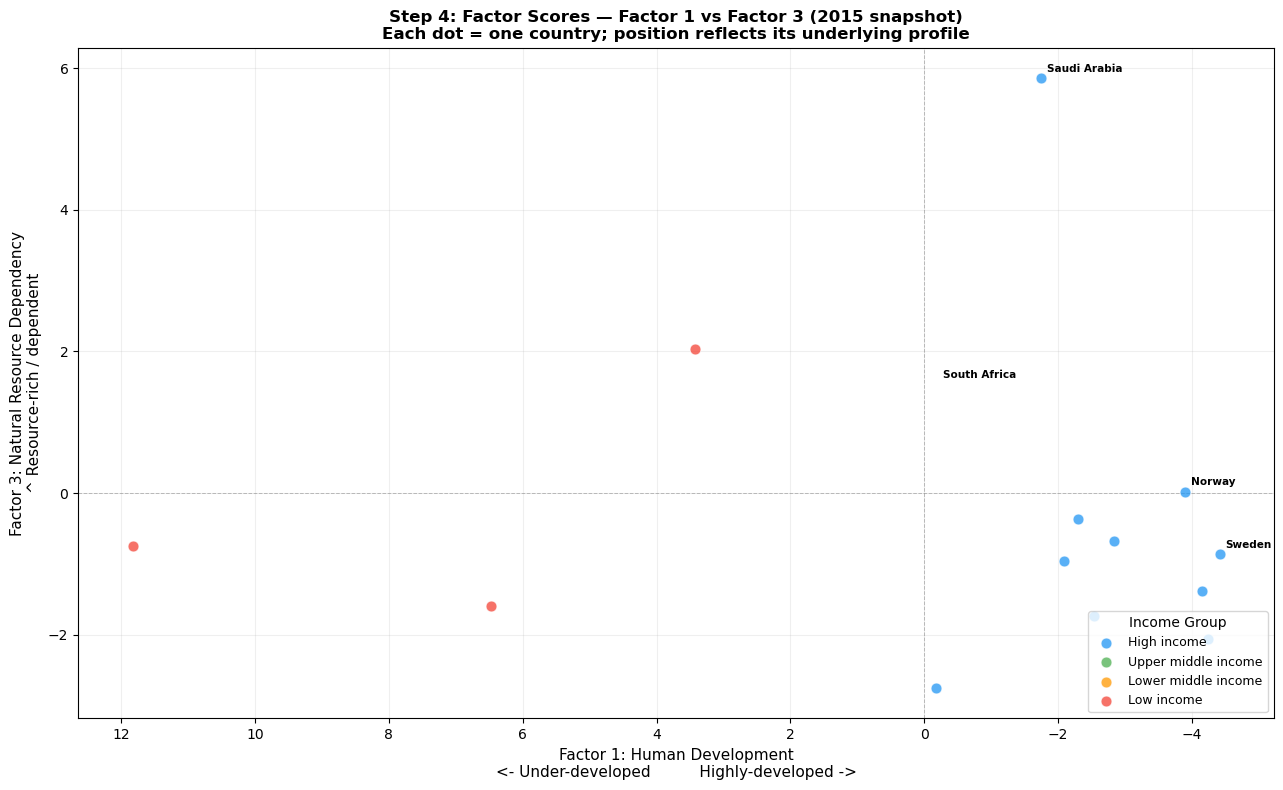

Saved: step4_factor_scores.png

Saved: factor_scores_all_years.csv
This file contains each country-year's score on all 6 factors.


In [2]:
"""
=============================================================
FACTOR ANALYSIS — World Sustainability Dataset (2000–2018)
=============================================================
This script walks through a complete factor analysis pipeline:
  1. Load & clean the data
  2. Standardise variables
  3. Build the correlation matrix
  4. Run PCA to find eigenvalues (scree plot)
  5. Extract & rotate factors (Varimax)
  6. Plot factor loadings heatmap
  7. Compute & visualise factor scores per country

Requirements: pandas, numpy, scikit-learn, matplotlib, seaborn
Install:  pip install pandas numpy scikit-learn matplotlib seaborn
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# ─────────────────────────────────────────────────────────────
# STEP 1: LOAD & CLEAN THE DATA
# ─────────────────────────────────────────────────────────────

df = pd.read_csv('WorldSustainabilityDataset.csv')  # update path if needed

# Drop non-numeric identifier columns and absolute-scale columns
# (GDP in USD and Population distort standardisation)
drop_cols = [
    'Year',
    'Population, total - SP.POP.TOTL',
    'GDP (current US$) - NY.GDP.MKTP.CD'
]
numeric_df = df.select_dtypes(include='number').drop(columns=drop_cols, errors='ignore')

# Drop columns where more than 40% of values are missing
# (too much imputation would distort the factor structure)
MISSING_THRESHOLD = 0.40
col_missing = numeric_df.isnull().mean()
numeric_df = numeric_df[col_missing[col_missing <= MISSING_THRESHOLD].index]

# Drop any remaining rows that still have NaN values
clean_df = numeric_df.dropna()

# Create short variable names for plots (strip the World Bank code suffix)
short_names = [c.split(' - ')[0].strip()[:45] for c in clean_df.columns]

print(f"Variables after cleaning:    {clean_df.shape[1]}")
print(f"Observations after cleaning: {clean_df.shape[0]}")


# ─────────────────────────────────────────────────────────────
# STEP 2: STANDARDISE THE DATA (z-scores)
# ─────────────────────────────────────────────────────────────
# Factor analysis assumes variables are on a comparable scale.
# StandardScaler transforms each variable to mean=0, std=1.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean_df)


# ─────────────────────────────────────────────────────────────
# STEP 3: CORRELATION MATRIX
# ─────────────────────────────────────────────────────────────
# This is the matrix your supervisor mentioned.
# It shows how strongly every pair of variables moves together.
# Factor analysis decomposes this matrix to find hidden patterns.

corr_matrix = np.corrcoef(X_scaled.T)  # shape: (n_variables x n_variables)

fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.7, label='Correlation coefficient')
ax.set_xticks(range(len(short_names)))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=90, fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
ax.set_title('Step 1: Correlation Matrix of All Variables\n'
             '(Red = positive, Blue = negative — clusters hint at factors)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('step1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: step1_correlation_matrix.png")


# ─────────────────────────────────────────────────────────────
# STEP 4: EIGENVALUES & SCREE PLOT — decide how many factors
# ─────────────────────────────────────────────────────────────
# PCA (Principal Component Analysis) decomposes the correlation
# matrix into eigenvalues and eigenvectors.
#
# Eigenvalue = how much variance a factor explains.
# Rule of thumb (Kaiser criterion): keep factors with eigenvalue > 1,
# meaning they explain more variance than a single original variable.

pca_full = PCA()
pca_full.fit(X_scaled)

eigenvalues = pca_full.explained_variance_
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_above_1 = sum(eigenvalues > 1)

print(f"\nKaiser criterion: {n_above_1} factors have eigenvalue > 1")
print("\nEigenvalues for first 12 factors:")
for i, (ev, cv) in enumerate(zip(eigenvalues[:12], cumvar[:12])):
    marker = " <- keep" if ev > 1 else ""
    print(f"  Factor {i+1:2d}: eigenvalue = {ev:.3f}  | cumulative variance = {cv:.1f}%{marker}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 2: How Many Factors Should We Keep?', fontsize=14, fontweight='bold')

# Left: Scree plot
components = range(1, len(eigenvalues) + 1)
ax1.plot(components, eigenvalues, 'o-', color='steelblue', linewidth=2, markersize=6)
ax1.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Kaiser criterion (eigenvalue = 1)')
ax1.fill_between(components, eigenvalues, 1,
                  where=[e > 1 for e in eigenvalues],
                  alpha=0.2, color='steelblue', label='Factors to keep')
ax1.set_xlabel('Factor Number', fontsize=11)
ax1.set_ylabel('Eigenvalue', fontsize=11)
ax1.set_title('Scree Plot\n(Keep factors above the red line)', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_xlim(0.5, 20)
ax1.grid(alpha=0.3)

# Right: Cumulative variance
ax2.bar(range(1, 16), cumvar[:15], color='steelblue', alpha=0.7, edgecolor='white')
ax2.axhline(y=70, color='green', linestyle='--', linewidth=1.5, label='70% threshold')
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=1.5, label='80% threshold')
for i, v in enumerate(cumvar[:15]):
    if i < 10:
        ax2.text(i + 1, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax2.set_xlabel('Number of Factors', fontsize=11)
ax2.set_ylabel('Cumulative Variance Explained (%)', fontsize=11)
ax2.set_title('Cumulative Variance Explained', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('step2_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: step2_scree_plot.png")


# ─────────────────────────────────────────────────────────────
# STEP 5: EXTRACT FACTORS & APPLY VARIMAX ROTATION
# ─────────────────────────────────────────────────────────────
# We keep 6 factors (all have eigenvalue > 1, explain 66.6% variance).
#
# Factor loadings = how strongly each variable relates to each factor.
# Raw loadings are often hard to interpret because each variable
# spreads its weight across many factors.
#
# Varimax rotation redistributes the loadings so each variable
# loads strongly on ideally just ONE factor — making factors
# easier to name and interpret.

N_FACTORS = 6  # change this if you want to try more/fewer

pca = PCA(n_components=N_FACTORS)
pca.fit(X_scaled)
factor_scores_unrotated = pca.transform(X_scaled)

# Raw loadings matrix: shape (n_variables, n_factors)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)


def varimax(Phi, gamma=1.0, q=100, tol=1e-6):
    """
    Varimax rotation algorithm.
    Rotates the loadings matrix so each variable loads on as few
    factors as possible — making factors more interpretable.

    Parameters
    ----------
    Phi : array (n_variables, n_factors)  — unrotated loadings
    gamma : float  — 1.0 = standard varimax
    q : int        — max iterations
    tol : float    — convergence tolerance

    Returns
    -------
    rotated_loadings : array (n_variables, n_factors)
    R : rotation matrix used (also applied to scores)
    """
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda ** 3 - (gamma / p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
        d = np.sum(s)
        if d_old != 0 and d / d_old < 1 + tol:
            break
    return Phi @ R, R


rotated_loadings, R = varimax(loadings)

# Apply same rotation to factor scores so they stay consistent
rotated_scores = factor_scores_unrotated @ R

# Build a labelled DataFrame of loadings for easy inspection
factor_cols = [f'Factor {i+1}' for i in range(N_FACTORS)]
loadings_df = pd.DataFrame(rotated_loadings, index=short_names, columns=factor_cols)

# Print top-loading variables per factor
print("\n" + "=" * 65)
print("TOP VARIABLES PER FACTOR  (|loading| > 0.45)")
print("=" * 65)
for j, fname in enumerate(factor_cols):
    col = loadings_df[fname]
    top = col[np.abs(col) > 0.45].sort_values(key=abs, ascending=False)
    var_explained = pca.explained_variance_ratio_[j] * 100
    print(f"\n{fname}  ({var_explained:.1f}% variance explained)")
    print("-" * 50)
    for var_name, loading in top.items():
        direction = "HIGH" if loading > 0 else "LOW "
        print(f"  {direction} ({loading:+.2f})  {var_name[:55]}")


# ─────────────────────────────────────────────────────────────
# STEP 6: FACTOR LOADINGS HEATMAP
# ─────────────────────────────────────────────────────────────
# Visualise the loadings matrix.
# Variables are sorted by which factor they load on most strongly.
# Strong colours (red/blue) = that variable is important for that factor.
# Near-white = that variable barely relates to that factor.

dominant_factor = np.abs(rotated_loadings).argmax(axis=1)
sort_order = np.argsort(dominant_factor)
loadings_sorted = loadings_df.iloc[sort_order]

fig, ax = plt.subplots(figsize=(12, 14))
im = ax.imshow(loadings_sorted.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.6, label='Loading (strength of relationship)')

ax.set_xticks(range(N_FACTORS))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(loadings_sorted.columns, fontsize=11, fontweight='bold')
ax.set_yticklabels(loadings_sorted.index, fontsize=8)

# Annotate each cell with its loading value
for i in range(len(short_names)):
    for j in range(N_FACTORS):
        val = loadings_sorted.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

ax.set_title(f'Step 3: Factor Loadings Matrix (Varimax Rotation, {N_FACTORS} Factors)\n'
             "Strong loadings (|value| > 0.5) define each factor's meaning",
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('step3_factor_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: step3_factor_loadings.png")


# ─────────────────────────────────────────────────────────────
# STEP 7: FACTOR SCORES — country positions on Factor 1 vs 3
# ─────────────────────────────────────────────────────────────
# Factor scores tell us where each country-year sits on each factor.
# Positive score = country is high on that factor's defining variables.
# Negative score = country is low on them.
#
# Here we plot Factor 1 (Human Development) vs Factor 3 (Resource Dependency)
# using a 2015 snapshot and colour by income group.

meta = df[['Country Name', 'Year', 'Income Classification (World Bank Definition)']].loc[clean_df.index]

scores_df = pd.DataFrame(rotated_scores, columns=factor_cols)
scores_df['Country'] = meta['Country Name'].values
scores_df['Year'] = meta['Year'].values
scores_df['Income'] = meta['Income Classification (World Bank Definition)'].values

snap = scores_df[scores_df['Year'] == 2015].copy()

income_colors = {
    'High income': '#2196F3',
    'Upper middle income': '#4CAF50',
    'Lower middle income': '#FF9800',
    'Low income': '#F44336'
}
snap['color'] = snap['Income'].map(income_colors).fillna('#999999')

fig, ax = plt.subplots(figsize=(13, 8))

for income, color in income_colors.items():
    sub = snap[snap['Income'] == income]
    ax.scatter(sub['Factor 1'], sub['Factor 3'], c=color, s=60, alpha=0.75,
               edgecolors='white', linewidth=0.5, label=income, zorder=3)

# Label a selection of notable countries
notable = ['United States', 'China', 'India', 'Nigeria', 'Brazil',
           'Norway', 'Saudi Arabia', 'Bangladesh', 'Germany', 'Ethiopia',
           'South Africa', 'Indonesia', 'Venezuela, RB', 'Sweden']
for _, row in snap.iterrows():
    if row['Country'] in notable:
        ax.annotate(row['Country'], (row['Factor 1'], row['Factor 3']),
                    fontsize=7.5, ha='left', va='bottom',
                    xytext=(4, 3), textcoords='offset points',
                    fontweight='bold')

ax.axhline(0, color='grey', linewidth=0.7, linestyle='--', alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.7, linestyle='--', alpha=0.5)
ax.invert_xaxis()  # flip so right = more developed
ax.set_xlabel('Factor 1: Human Development\n<- Under-developed          Highly-developed ->', fontsize=11)
ax.set_ylabel('Factor 3: Natural Resource Dependency\n^ Resource-rich / dependent', fontsize=11)
ax.set_title('Step 4: Factor Scores — Factor 1 vs Factor 3 (2015 snapshot)\n'
             'Each dot = one country; position reflects its underlying profile',
             fontsize=12, fontweight='bold')
ax.legend(title='Income Group', loc='lower right', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('step4_factor_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: step4_factor_scores.png")


# ─────────────────────────────────────────────────────────────
# OPTIONAL: EXPORT FACTOR SCORES TO CSV
# ─────────────────────────────────────────────────────────────
# Useful if you want to use the factor scores in further analysis
# (e.g. regression, clustering, time-series plots).

scores_df.to_csv('factor_scores_all_years.csv', index=False)
print("\nSaved: factor_scores_all_years.csv")
print("This file contains each country-year's score on all 6 factors.")